In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import LogisticRegression 
df = pd.read_csv('customer_segmentation_ecom - LMS (1).csv')
df

,Customer_ID,Age,City,Tenure_Months,Recency_Days,Frequency_Last_6M,Monetary_Total_Spend_6M,Avg_Order_Value,Avg_Items_Per_Order,Total_Orders_Lifetime,...,Cart_Abandonment_Rate,Wishlist_Count,Discount_Usage_Rate,Return_Rate,Support_Tickets_6M,Loyalty_Points_Balance,Loyalty_Tier,Favorite_Color,Lucky_Number,Keyboard_Layout
0,CUST107185,32.0,Bengaluru,23.4,61.0,2.0,1760.21,1056.83,2.04,17,...,0.752,10,0.491,0.164,1.0,772.0,Gold,Black,83,AZERTY
1,CUST110439,43.0,Delhi,34.0,12.0,4.0,4292.38,2326.75,2.09,28,...,0.698,9,0.454,0.090,2.0,966.0,Platinum,Black,87,QWERTY
2,CUST110714,36.0,Pune,22.6,74.0,7.0,17214.45,2205.26,1.42,32,...,0.749,12,0.475,0.085,1.0,2562.0,Platinum,Yellow,19,QWERTY
3,CUST110882,32.0,Mumbai,3.1,38.0,3.0,3780.40,1702.20,2.05,10,...,0.210,6,0.215,0.092,0.0,501.0,Gold,Black,83,QWERTY
4,CUST109031,27.0,Kolkata,34.6,27.0,7.0,10488.03,3138.04,3.23,26,...,0.467,5,0.493,0.548,6.0,1662.0,Platinum,Black,76,QWERTY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12055,CUST104307,54.0,Pune,54.6,51.0,12.0,20194.37,2149.99,3.92,39,...,0.337,8,0.757,0.037,0.0,3272.0,Platinum,Green,28,QWERTY
12056,CUST105699,18.0,Hyderabad,59.3,7.0,15.0,41707.11,3511.81,3.36,69,...,0.121,6,0.227,0.119,1.0,6721.0,Platinum,Green,77,QWERTY
12057,CUST110742,38.0,Hyderabad,22.8,7.0,22.0,109093.74,NaN,1.73,55,...,0.231,7,0.098,0.092,1.0,12536.0,Platinum,Blue,44,AZERTY
12058,CUST100537,28.0,Bengaluru,34.8,7.0,23.0,187975.07,7280.85,2.01,62,...,0.221,7,0.133,0.078,0.0,22063.0,Platinum,White,62,QWERTY


In [5]:
df.isnull().sum()

Customer_ID                    0
Age                            0
City                           0
Tenure_Months                  0
Recency_Days                   0
Frequency_Last_6M              0
Monetary_Total_Spend_6M        0
Avg_Order_Value                0
Avg_Items_Per_Order            0
Total_Orders_Lifetime          0
Spend_Electronics_6M           0
Spend_Fashion_6M               0
Spend_Grocery_6M               0
Spend_Beauty_6M                0
Spend_HomeKitchen_6M           0
App_Visits_Per_Week            0
Time_Spent_Minutes_Per_Week    0
Cart_Abandonment_Rate          0
Wishlist_Count                 0
Discount_Usage_Rate            0
Return_Rate                    0
Support_Tickets_6M             0
Loyalty_Points_Balance         0
Loyalty_Tier                   0
Favorite_Color                 0
Lucky_Number                   0
Keyboard_Layout                0
dtype: int64

In [3]:
df.duplicated().sum()

np.int64(60)

In [4]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [6]:
for i in df.select_dtypes(include='object').columns:
    print(i)
    l=LabelEncoder()
    df[i]=l.fit_transform(df[i])

Customer_ID
City
Loyalty_Tier
Favorite_Color
Keyboard_Layout


Text(0, 0.5, 'WCSS')

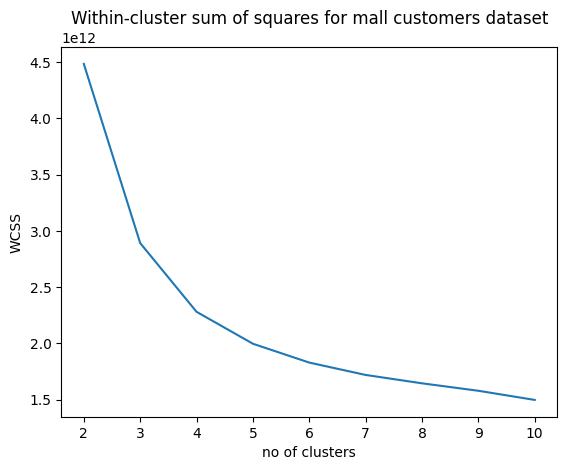

In [7]:
import matplotlib.pyplot as plt
'''
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
'''
from sklearn.cluster import KMeans
wss= []
for k in range(2,11):
    model = KMeans(n_clusters=k,random_state=42)
    model.fit(df) # training
    wss.append(model.inertia_)

plt.plot(range(2,11),wss)
plt.title('Within-cluster sum of squares for mall customers dataset')
plt.xlabel('no of clusters')
plt.ylabel('WCSS')


In [9]:
kmeans_1 = KMeans(n_clusters=4,random_state=42)
kmeans_1.fit(df)# training
#adding clusters labels to original dataset
df['cluster'] = kmeans_1.labels_ 
from sklearn.metrics import silhouette_score
# computing silhouette score for k values from 2 to 10
predict_1 = kmeans_1.predict(df)
score = silhouette_score(df,predict_1)
print(score)
print(df)
for i in range(4):
    cluster_df =df[df['cluster']== i]
    print(f'cluster {i}:\n{cluster_df}\n')

0.49917581819258294
       Customer_ID   Age  City  Tenure_Months  Recency_Days  \
0             7185  32.0     1           23.4          61.0   
1            10439  43.0     3           34.0          12.0   
2            10714  36.0     9           22.6          74.0   
3            10882  32.0     8            3.1          38.0   
4             9031  27.0     6           34.6          27.0   
...            ...   ...   ...            ...           ...   
12055         4307  54.0     9           54.6          51.0   
12056         5699  18.0     4           59.3           7.0   
12057        10742  38.0     4           22.8           7.0   
12058          537  28.0     1           34.8           7.0   
12059         9412  41.0     9           33.0           2.0   

       Frequency_Last_6M  Monetary_Total_Spend_6M  Avg_Order_Value  \
0                    2.0                  1760.21          1056.83   
1                    4.0                  4292.38          2326.75   
2            